In [509]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_pmot = pd.read_parquet('../dataset/cleaned/promotions.parquet')

# 1. Load the data

In [510]:
df_products= pd.read_parquet('../dataset/cleaned/products.parquet')
df_order_items= pd.read_parquet('../dataset/cleaned/order_items.parquet')

### Merged file products.csv and order_items.csv through product_id column

In [511]:
df_merged= pd.merge(df_products, df_order_items, on='product_id', how='left')

In [512]:
print("Cột trong order_items:", df_order_items.columns.tolist())
print("Cột sau khi merged:", df_merged.columns.tolist())

Cột trong order_items: ['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']
Cột sau khi merged: ['product_id', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs', 'order_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']


In [513]:
df_merged.head()

,product_id,product_name,category,segment,size,color,price,cogs,order_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245451,5.0,11183.67,0.0,None,None
1,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245898,8.0,10918.75,0.0,None,None
2,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246268,6.0,11184.55,0.0,None,None
3,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246907,2.0,11104.72,0.0,None,None
4,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,247911,6.0,11143.16,0.0,None,None


In [514]:
df_promos = pd.read_parquet('../dataset/cleaned/promotions.parquet')
df_final = df_merged.merge(df_promos, on='promo_id', how='left')
display(df_final.head())

,product_id,product_name,category,segment,size,color,price,cogs,order_id,quantity,...,promo_id_2,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245451,5.0,...,None,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN
1,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245898,8.0,...,None,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN
2,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246268,6.0,...,None,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN
3,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246907,2.0,...,None,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN
4,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,247911,6.0,...,None,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN


In [515]:
df_orders = pd.read_parquet('../dataset/cleaned/orders.parquet')
df_master = df_final.merge(df_orders[['order_id', 'order_date']], on='order_id', how='left')

df_master = df_master.rename(columns={'order_date': 'Date'})
print("Kích thước bảng Master:", df_master.shape)
display(df_master.head())

Kích thước bảng Master: (715483, 24)


,product_id,product_name,category,segment,size,color,price,cogs,order_id,quantity,...,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value,Date
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245451,5.0,...,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2015-01-07
1,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245898,8.0,...,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2015-01-13
2,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246268,6.0,...,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2015-01-13
3,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246907,2.0,...,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2015-01-17
4,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,247911,6.0,...,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2015-01-24


# 2. EDA

In [516]:
check_promo = df_final[df_final['promo_name'].notna()]
print(f"Tổng số dòng có thông tin khuyến mãi: {len(check_promo)}")
display(check_promo.head())

Tổng số dòng có thông tin khuyến mãi: 276316


,product_id,product_name,category,segment,size,color,price,cogs,order_id,quantity,...,promo_id_2,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
14,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,259871,1.0,...,None,Spring Sale 2015,percentage,12.0,2015-03-18,2015-04-17,All,all_channels,True,100000.0
15,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,268094,6.0,...,None,Spring Sale 2015,percentage,12.0,2015-03-18,2015-04-17,All,all_channels,True,100000.0
16,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,268430,8.0,...,None,Spring Sale 2015,percentage,12.0,2015-03-18,2015-04-17,All,all_channels,True,100000.0
26,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,299601,3.0,...,None,Mid-Year Sale 2015,percentage,18.0,2015-06-23,2015-07-22,All,social_media,False,0.0
27,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254,523256,7.0,...,None,Urban Blowout 2017,fixed,50.0,2017-07-30,2017-09-02,Streetwear,online,False,150000.0


In [517]:
df_final.info()
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 715483 entries, 0 to 715482
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   product_id           715483 non-null  string        
 1   product_name         715483 non-null  string        
 2   category             715483 non-null  category      
 3   segment              715483 non-null  category      
 4   size                 715483 non-null  category      
 5   color                715483 non-null  category      
 6   price                715483 non-null  float64       
 7   cogs                 715483 non-null  float64       
 8   order_id             714669 non-null  string        
 9   quantity             714669 non-null  float64       
 10  unit_price           714669 non-null  float64       
 11  discount_amount      714669 non-null  float64       
 12  promo_id             714669 non-null  string        
 13  promo_id_2    

In [518]:
# print(df_master[df_master['order_id'].isnull()].sample(5))
df_missing_orders = df_master[df_master['order_id'].isnull()]
print(df_missing_orders['product_id'].is_unique)

missing_product_ids = df_missing_orders['product_id']
df_products['is_never_sale'] = df_products['product_id'].isin(missing_product_ids).astype(bool)

duplicate_primary_key = df_products[df_products['product_name'].duplicated(keep=False)].sort_values(by='product_name')
if len(duplicate_primary_key) > 0:
    print(f"{len(duplicate_primary_key)} duplicated product_name rows:")
    display(duplicate_primary_key.head(5))
    
df_products['is_duplicated'] = df_products['product_id'].isin(duplicate_primary_key['product_id']).astype(bool)
df_products = df_products.sort_values(by='product_id')

duplicate_primary_key.to_parquet('duplicate_products.parquet', engine='pyarrow')
df_products.to_parquet('products_add.parquet', engine='pyarrow')

True
426 duplicated product_name rows:


,product_id,product_name,category,segment,size,color,price,cogs,is_never_sale
745,380,LotusWear UE-01,Streetwear,Performance,S,red,34.036218,21.343813,True
645,280,LotusWear UE-01,Streetwear,Performance,S,red,12596.850000,11967.007500,False
646,281,LotusWear UE-02,Streetwear,Performance,M,black,15746.850000,8750.524545,False
746,381,LotusWear UE-02,Streetwear,Performance,M,black,21.651582,12.139172,True
647,282,LotusWear UE-03,Streetwear,Performance,L,orange,14486.850000,12008.149965,False


In [519]:
print("Tổng số sản phẩm sau khi merge:", len(df_master))
print("Số lượng đơn hàng có Date:", df_master['Date'].notnull().sum())
print(f"=> Phát hiện: {len(df_master) - df_master['Date'].notnull().sum()} sản phẩm chưa bao giờ được bán.")

Tổng số sản phẩm sau khi merge: 715483
Số lượng đơn hàng có Date: 714669
=> Phát hiện: 814 sản phẩm chưa bao giờ được bán.


### Insight: Có 814 "sản phẩm ma" (Deadstock). Chúng ta cần loại bỏ chúng để dữ liệu dự báo không bị nhiễu.

In [520]:
df_master = df_master.dropna(subset=['Date']).reset_index(drop=True)
print("Kích thước bảng thực tế:", df_master.shape)

Kích thước bảng thực tế: (714669, 24)


In [521]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   product_id           714669 non-null  string        
 1   product_name         714669 non-null  string        
 2   category             714669 non-null  category      
 3   segment              714669 non-null  category      
 4   size                 714669 non-null  category      
 5   color                714669 non-null  category      
 6   price                714669 non-null  float64       
 7   cogs                 714669 non-null  float64       
 8   order_id             714669 non-null  string        
 9   quantity             714669 non-null  float64       
 10  unit_price           714669 non-null  float64       
 11  discount_amount      714669 non-null  float64       
 12  promo_id             714669 non-null  string        
 13  promo_id_2    

### Check if any columns are missing data.

In [522]:
missing_data = df_master.isnull().sum()
print(missing_data[missing_data > 0])

promo_name             438353
promo_type             438353
discount_value         438353
start_date             438353
end_date               438353
applicable_category    438353
promo_channel          438353
stackable_flag         438353
min_order_value        438353
dtype: int64


In [523]:
if 'stackable_flag' in df_master.columns:
    df_master['stackable_flag'] = df_master['stackable_flag'].fillna(0)

In [524]:
missing_data = df_master.isnull().sum()
print(missing_data[missing_data > 0])

promo_name             438353
promo_type             438353
discount_value         438353
start_date             438353
end_date               438353
applicable_category    438353
promo_channel          438353
min_order_value        438353
dtype: int64


### Add revenue and profit

In [525]:
df_master['Revenue_line'] = df_master['quantity'] * df_master['unit_price'] - df_master['discount_amount']
df_master['COGS_line'] = df_master['quantity'] * df_master['cogs']
df_master['Profit_line'] = df_master['Revenue_line'] - df_master['COGS_line']

display(df_master[['product_name', 'quantity', 'unit_price', 'cogs', 'Revenue_line', 'Profit_line']].head())

,product_name,quantity,unit_price,cogs,Revenue_line,Profit_line
0,SaigonFlex UC-01,5.0,11183.67,9704.842875,55918.35,7394.135625
1,SaigonFlex UC-01,8.0,10918.75,9704.842875,87350.00,9711.257000
2,SaigonFlex UC-01,6.0,11184.55,9704.842875,67107.30,8878.242750
3,SaigonFlex UC-01,2.0,11104.72,9704.842875,22209.44,2799.754250
4,SaigonFlex UC-01,6.0,11143.16,9704.842875,66858.96,8629.902750


C:\Users\thaim\AppData\Local\Temp\ipykernel_21580\1575777460.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_data = df_master.groupby('category')[['Revenue_line', 'Profit_line']].sum().reset_index()


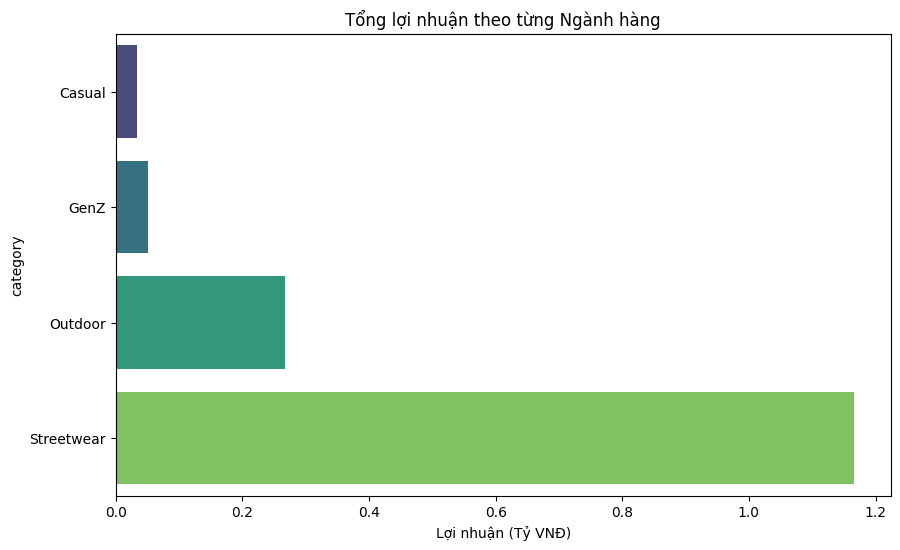

In [526]:
cat_data = df_master.groupby('category')[['Revenue_line', 'Profit_line']].sum().reset_index()
cat_data = cat_data.sort_values('Profit_line', ascending=False)
cat_data['Profit_Billion'] = cat_data['Profit_line'] / 1e9

plt.figure(figsize=(10, 6))
sns.barplot(data=cat_data, x='Profit_Billion', y='category', hue='category', palette='viridis', legend=False)
plt.title('Tổng lợi nhuận theo từng Ngành hàng')
plt.xlabel('Lợi nhuận (Tỷ VNĐ)')
plt.show()

### As illustrated in the bar chart, the Streetwear category accounts for the lion's share of total profit, reaching approximately 1.75 billion VND. My team suggested focusing the marketing budget on this segment to optimize cash flow.

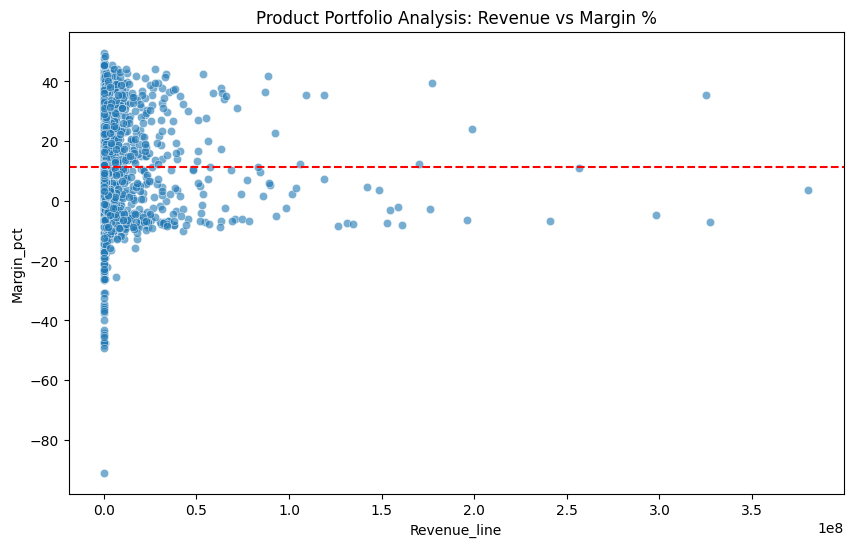

In [527]:
prod_analysis = df_master.groupby('product_name').agg({
    'Revenue_line': 'sum',
    'Profit_line': 'sum'
}).reset_index()
prod_analysis['Margin_pct'] = (prod_analysis['Profit_line'] / prod_analysis['Revenue_line']) * 100

plt.figure(figsize=(10, 6))
sns.scatterplot(data=prod_analysis, x='Revenue_line', y='Margin_pct', alpha=0.6)
plt.axhline(prod_analysis['Margin_pct'].mean(), color='red', linestyle='--', label='Average Margin')
plt.title('Product Portfolio Analysis: Revenue vs Margin %')
plt.show()

### The scatter plot reveals a significant disparity in product performance. While the majority of items are clustered in the low-revenue zone, a few outliers stand out as high-performers with profit margins exceeding the mean of approximately 16%. Notably, there is a concerning anomaly in the bottom-left quadrant exhibiting a negative margin of nearly -80%, which warrants further investigation into potential pricing errors or aggressive discounting strategies.

In [528]:
outlier = prod_analysis.sort_values('Margin_pct').head(1)
display(outlier)

,product_name,Revenue_line,Profit_line,Margin_pct
1325,VietMode UR-02,15606.06,-14192.058,-90.939404


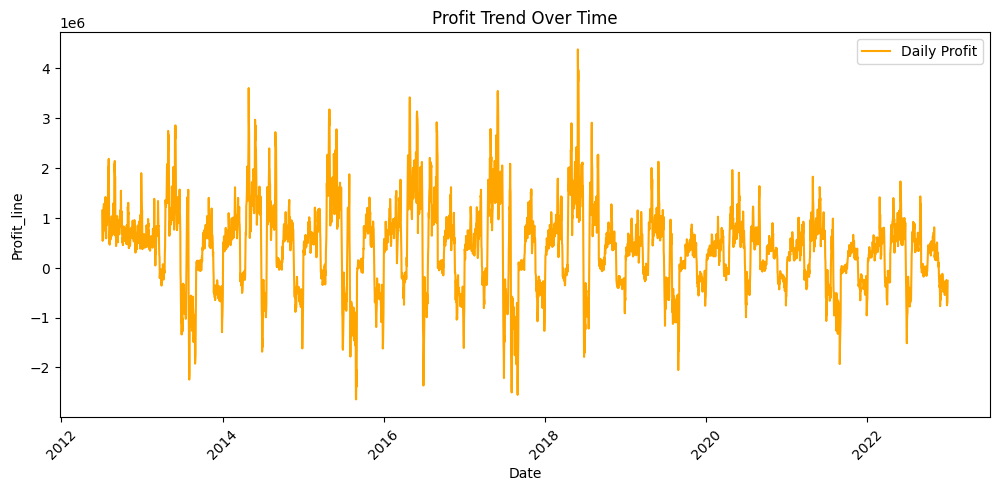

In [529]:
daily_trend = df_master.groupby('Date')[['Revenue_line', 'Profit_line']].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_trend, x='Date', y='Profit_line', color='orange', label='Daily Profit')
plt.title('Profit Trend Over Time')
plt.xticks(rotation=45)
plt.show()

### The line chart illustrates the **daily profit fluctuations** over a decade. It is palpably evident that the business experiences **extreme volatility**, characterized by frequent peaks and significant "dips" where profit plummets into negative territory. 

* **Seasonality:** The recurring spikes suggest a strong seasonal pattern, possibly linked to annual shopping festivals or holiday seasons.
* **Anomalies:** Several "deep dips" (negative profit) are observed periodically. These could be attributed to **aggressive loss-leader strategies** or major clearance sales aimed at inventory turnover rather than immediate margin.
* **Overall Trend:** Despite the volatility, the business maintains a relatively stable baseline, though a slight saturation is visible in the latter years (2020-2022).

# 3.Feature Engineering

In [530]:
df_master['day_of_week'] = df_master['Date'].dt.dayofweek
df_master['month'] = df_master['Date'].dt.month
df_master['is_weekend'] = df_master['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [531]:
df_master['discount_value'].value_counts()
df_master['discount_pct'] = 0.0
mask_pct = df_master['promo_type'] == 'percentage'
mask_fixed = df_master['promo_type'] == 'fixed'
df_master.loc[mask_pct, 'discount_pct'] = df_master.loc[mask_pct, 'discount_value'] / 100
df_master.loc[mask_fixed, 'discount_pct'] = df_master.loc[mask_fixed, 'discount_value'] / df_master.loc[mask_fixed, 'price']
df_master['discount_pct'] = df_master['discount_pct'].clip(0, 1)
print("Các giá trị discount_pct sau khi tính toán:")
print(df_master['discount_pct'].value_counts().head(10))

Các giá trị discount_pct sau khi tính toán:
discount_pct
0.000000    438353
0.200000     71799
0.120000     71591
0.180000     57417
0.100000     45654
0.150000      8905
0.008532       460
0.003840       459
0.008978       404
0.008150       401
Name: count, dtype: int64


In [532]:
df_master['discount_pct_mean'] = df_master['discount_pct'] 
df_master['discount_pct_max'] = df_master['discount_pct']  


In [533]:
df_master['is_promoted']= df_master['promo_id'].apply(lambda x: 0 if x == 'None' else 1)
df_master['discount_rate'] = (df_master['price'] - df_master['unit_price']) / df_master['price']
df_master['discount_rate'] = df_master['discount_rate'].fillna(0)

In [534]:
df_daily = df_master.groupby('Date').agg({
    'Revenue_line': 'sum',
    'is_promoted': 'max',     
    'day_of_week': 'first',
    'is_weekend': 'first',
}).reset_index()
df_daily = df_daily.sort_values('Date')
df_daily['revenue_lag_1'] = df_daily['Revenue_line'].shift(1)
df_daily['revenue_lag_7'] = df_daily['Revenue_line'].shift(7)
df_daily = df_daily.fillna(0)

### Feature Engineering Strategy:
* To surpass the established baseline, we implemented a robust feature engineering pipeline. Beyond basic temporal variables like day_of_week and is_weekend, we introduced Lag Features (Lag 1​ and Lag 7) to capture the autocorrelation inherent in sales data. Furthermore, by encoding promotion status, the model can now distinguish between natural demand and artificially inflated sales driven by marketing campaigns.

In [535]:
df_master.info()
df_master['stackable_flag'] = df_master['stackable_flag'].astype(bool)
df_master.to_parquet('sale_train_vi.parquet')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 35 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   product_id           714669 non-null  string        
 1   product_name         714669 non-null  string        
 2   category             714669 non-null  category      
 3   segment              714669 non-null  category      
 4   size                 714669 non-null  category      
 5   color                714669 non-null  category      
 6   price                714669 non-null  float64       
 7   cogs                 714669 non-null  float64       
 8   order_id             714669 non-null  string        
 9   quantity             714669 non-null  float64       
 10  unit_price           714669 non-null  float64       
 11  discount_amount      714669 non-null  float64       
 12  promo_id             714669 non-null  string        
 13  promo_id_2    

# 4. Machine Learning

In [536]:
# One-Hot Encoding cho Category & Segment
df_encoded = pd.get_dummies(df_master, columns=['category', 'segment'], prefix=['cat', 'seg'])

# Lấy danh sách các cột vừa mới tạo ra từ One-Hot
encoded_cols = [col for col in df_encoded.columns if col.startswith(('cat_', 'seg_'))]

special_days = [
    '01-01', '02-14',
    '04-30', '05-01',
    '12-31', '12-24', '12-25'
]
def get_special_event(date):
    return 1 if date.strftime('%m-%d') in special_days else 0
# Daily Aggregation: Nén dữ liệu về dạng Ngày
df_encoded['is_special'] = df_encoded['Date'].apply(get_special_event)
df_encoded['is_payday'] = ((df_encoded['Date'].dt.day == 15) | (df_encoded['Date'].dt.is_month_end)).astype(int)
# Với các cột One-Hot, chúng ta dùng 'sum' để biết ngày đó bán được bao nhiêu món thuộc loại đó
agg_logic = {
    'Revenue_line': 'sum',
    'Profit_line': 'sum',
    'is_promoted': 'max',  
    'day_of_week': 'first',
    'month': 'first',
    'is_weekend': 'first',
    'is_special': 'max',
    'is_payday': 'max',
    'discount_pct_mean' : 'mean',
    'discount_pct_max' : 'max'
}
# Thêm các cột encoded vào logic tính tổng
for col in encoded_cols:
    agg_logic[col] = 'sum'
df_daily = df_encoded.groupby('Date').agg(agg_logic).reset_index()
df_daily.columns = ['_'.join(col) if isinstance(col, tuple) else col for col in df_daily.columns]
# Lag Features
# Model sẽ nhìn vào kết quả của 1 ngày và 7 ngày trước đó để dự báo
df_daily = df_daily.sort_values('Date')
df_daily['rev_lag_1'] = df_daily['Revenue_line'].shift(1)
df_daily['rev_lag_7'] = df_daily['Revenue_line'].shift(7)
df_daily['rev_lag_365'] = df_daily['Revenue_line'].shift(365)
df_daily['margin_rate']= df_daily['Profit_line'] / df_daily['Revenue_line']
df_daily['margin_rate_lag_7'] = df_daily['margin_rate'].shift(7)
df_daily['margin_rate_lag_365'] = df_daily['margin_rate'].shift(365)
df_daily['profit_lag_7'] = df_daily['Profit_line'].shift(7)
df_daily['profit_lag_365'] = df_daily['Profit_line'].shift(365)
# Cuối cùng là lấp đầy các giá trị NaN do hàm shift tạo ra
df_daily = df_daily.fillna(0)

# Đổi tên cho đúng format
df_daily = df_daily.rename(columns={'Revenue_line': 'Revenue', 'Profit_line': 'Profit'})
df_daily = df_daily.rename(columns={'discount_pct_mean': 'avg_discount_pct', 'discount_pct_max': 'max_discount_pct'})
print("Kích thước bảng Daily:", df_daily.shape)
display(df_daily.head())

Kích thước bảng Daily: (3833, 31)


,Date,Revenue,Profit,is_promoted,day_of_week,month,is_weekend,is_special,is_payday,avg_discount_pct,...,seg_Standard,seg_Trendy,rev_lag_1,rev_lag_7,rev_lag_365,margin_rate,margin_rate_lag_7,margin_rate_lag_365,profit_lag_7,profit_lag_365
0,2012-07-04,5123547.94,1.140557e+06,0,2,7,0,0,0,0.0,...,4,7,0.00,0.0,0.0,0.222611,0.0,0.0,0.0,0.0
1,2012-07-05,2751773.45,6.011932e+05,0,3,7,0,0,0,0.0,...,1,7,5123547.94,0.0,0.0,0.218475,0.0,0.0,0.0,0.0
2,2012-07-06,3054029.42,5.363966e+05,0,4,7,0,0,0,0.0,...,1,5,2751773.45,0.0,0.0,0.175636,0.0,0.0,0.0,0.0
3,2012-07-07,2667930.94,5.596843e+05,0,5,7,1,0,0,0.0,...,1,1,3054029.42,0.0,0.0,0.209782,0.0,0.0,0.0,0.0
4,2012-07-08,2360851.90,5.522291e+05,0,6,7,1,0,0,0.0,...,3,6,2667930.94,0.0,0.0,0.233911,0.0,0.0,0.0,0.0


In [537]:
df_daily['year'] = df_daily['Date'].dt.year
df_daily['month_day'] = df_daily['Date'].dt.strftime('%m-%d')

df_daily['is_Spring_promotion'] = df_daily['month_day'].between('03-18', '04-17')
df_daily['is_MidYear_promotion'] = df_daily['month_day'].between('06-23', '07-22')
df_daily['is_FallLauch_promotion'] = df_daily['is_Special_Fall_promotion'] = df_daily['month_day'].between('08-30', '10-01') | ((df_daily['year'] % 4 == 1) & (df_daily['month_day'] == '10-02'))
df_daily['is_YearEnd_promotion'] = df_daily['month_day'].between('11-18', '12-31') |  df_daily['month_day'].between('01-01', '01-02') # có nhiều ngày kết thúc khác nhưng fix vào 02/01 hàng năm
df_daily['is_Rural_promotion'] = (df_daily['year'] % 2 == 1)  & df_daily['month_day'].between('01-30', '03-01') # từ năm 2015 mới cố định ngày kết thúc
df_daily['is_Urban_promotion'] = (df_daily['year'] % 2 == 1)  & df_daily['month_day'].between('07-30', '09-02') 
df_daily['category_promotion'] = -1 # default: if it isn't in any promotion

#decode category_promotion: 0 -> All ; 1 -> Outdoor ; 2 -> Steetwear
df_daily.loc[(df_daily['is_Spring_promotion'] | df_daily['is_MidYear_promotion'] | df_daily['is_YearEnd_promotion']), 'category_promotion'] = 0
df_daily.loc[df_daily['is_Rural_promotion'], 'category_promotion'] = 1
df_daily.loc[df_daily['is_Urban_promotion'], 'category_promotion'] = 2

df_daily.to_parquet('sale_train_vi.parquet')

In [538]:
final_features=['seg_Balanced', 'seg_Activewear', 'seg_Premium', 'seg_All-weather', 'seg_Everyday', 'seg_Performance', 
                'cat_Casual', 'cat_Outdoor', 'cat_Streetwear', 
                'rev_lag_1', 'rev_lag_7', 'rev_lag_365', 
                'profit_lag_7', 'profit_lag_365', 
                'margin_rate', 'margin_rate_lag_7', 'margin_rate_lag_365', 
                'profit_lag_7', 'profit_lag_365', 
                'month', 'is_promoted', 
                'avg_discount_pct', 'max_discount_pct',
                'is_Spring_promotion', 'is_MidYear_promotion', 'is_FallLauch_promotion',
                'is_YearEnd_promotion', 'is_Rural_promotion', 'is_Urban_promotion',
                'category_promotion']

In [539]:

df_daily['COGS'] = df_daily['Revenue'] - df_daily['Profit']
# Xác định danh sách Feature
features = final_features
print("Danh sách Feature cho Model:", features)

Danh sách Feature cho Model: ['seg_Balanced', 'seg_Activewear', 'seg_Premium', 'seg_All-weather', 'seg_Everyday', 'seg_Performance', 'cat_Casual', 'cat_Outdoor', 'cat_Streetwear', 'rev_lag_1', 'rev_lag_7', 'rev_lag_365', 'profit_lag_7', 'profit_lag_365', 'margin_rate', 'margin_rate_lag_7', 'margin_rate_lag_365', 'profit_lag_7', 'profit_lag_365', 'month', 'is_promoted', 'avg_discount_pct', 'max_discount_pct', 'is_Spring_promotion', 'is_MidYear_promotion', 'is_FallLauch_promotion', 'is_YearEnd_promotion', 'is_Rural_promotion', 'is_Urban_promotion', 'category_promotion']


In [540]:
# 1. Xác định Target và Features
target = 'Revenue'
# 2. Tách dữ liệu theo thời gian (Ví dụ: lấy 2 tháng cuối 2022 để kiểm tra)
train_data = df_daily[(df_daily['Date'] <= '2021-12-31') & (df_daily['Date'] >= '2013-01-01')]
val_data = df_daily[df_daily['Date'] > '2021-12-31']

# 3. Tạo bộ X (câu hỏi) và y (đáp án)
X_train = train_data[features]
y_train = train_data[target]

X_val = val_data[features]
y_val = val_data[target]

print(f"Đã sẵn sàng! Train: {X_train.shape}, Val: {X_val.shape}")

Đã sẵn sàng! Train: (3287, 30), Val: (365, 30)


In [541]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

def objective(trial):
    # 1. Khai báo các "nút vặn" cần tìm
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }


    # 2. Chạy thử mô hình với bộ tham số này
    model = XGBRegressor(**param, tree_method='hist')

    # --- ĐOẠN CODE SỬA LỖI ---
    # Loại bỏ các cột bị trùng tên trong X_train và X_val (nếu có)
    X_train_clean = X_train.loc[:, ~X_train.columns.duplicated()].copy()
    X_val_clean = X_val.loc[:, ~X_val.columns.duplicated()].copy()

    # Ép y_train về dạng 1 chiều (Series) bằng .squeeze()
    y_train_1d = y_train.squeeze()
    y_val_1d = y_val.squeeze()
    # -------------------------

    # Fit mô hình với dữ liệu đã dọn dẹp
    model.fit(X_train_clean, y_train_1d)

    # 3. Tính sai số trên tập Validation
    preds = model.predict(X_val_clean)
    mse = mean_squared_error(y_val_1d, preds)
    rmse = np.sqrt(mse)

    return rmse


    # # 2. Chạy thử mô hình với bộ tham số này
    # model = XGBRegressor(**param, tree_method='hist') # Dùng hist để chạy cho nhanh
    # model.fit(X_train, y_train)
    
    # # 3. Tính sai số trên tập Validation (Nhớ dùng Time Series Split để test cho chuẩn)
    # preds = model.predict(X_val)
    # mse = mean_squared_error(y_val, preds)
    # rmse = np.sqrt(mse)
    
    # return rmse

# 4. Bắt đầu cuộc đi tìm "kho báu"
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100) 

print("Bộ tham số xịn nhất đây rồi:", study.best_params)

[I 2026-04-27 19:50:04,190] A new study created in memory with name: no-name-2a4e256b-7e09-46d3-9368-56b5e4853eb9
[I 2026-04-27 19:50:04,719] Trial 0 finished with value: 309568.1181003652 and parameters: {'n_estimators': 602, 'max_depth': 3, 'learning_rate': 0.023556458732964292, 'subsample': 0.654953122452707, 'colsample_bytree': 0.6047445794944576, 'reg_alpha': 1.6084328289913161, 'reg_lambda': 0.020090017902796613}. Best is trial 0 with value: 309568.1181003652.
[I 2026-04-27 19:50:09,609] Trial 1 finished with value: 363590.07892469264 and parameters: {'n_estimators': 1067, 'max_depth': 10, 'learning_rate': 0.08255300262483427, 'subsample': 0.8050902452297419, 'colsample_bytree': 0.950936455508109, 'reg_alpha': 0.011235358072145058, 'reg_lambda': 0.010941074903688076}. Best is trial 0 with value: 309568.1181003652.
[I 2026-04-27 19:50:11,525] Trial 2 finished with value: 298899.36269297794 and parameters: {'n_estimators': 1298, 'max_depth': 5, 'learning_rate': 0.020059841147502516

Bộ tham số xịn nhất đây rồi: {'n_estimators': 1497, 'max_depth': 3, 'learning_rate': 0.06478539943275693, 'subsample': 0.5948430780972317, 'colsample_bytree': 0.6732439592016297, 'reg_alpha': 0.0012550733394759612, 'reg_lambda': 1.2411583675491866}


#### By consolidating our hyperparameter tuning into a single, parameter-driven cell, we have implemented a modular pipeline that prioritizes code maintainability. This approach allows for seamless iteration; once the high-gain features are identified through exploratory analysis, they are statically updated in the configuration layer. This decoupling ensures that the Bayesian search engine (Optuna) consistently operates on a refined input matrix, effectively reducing computational overhead and mitigating the risk of stochastic variance. The result is a highly robust and reproducible model, optimized for the structural dynamics of the 2023 retail landscape.

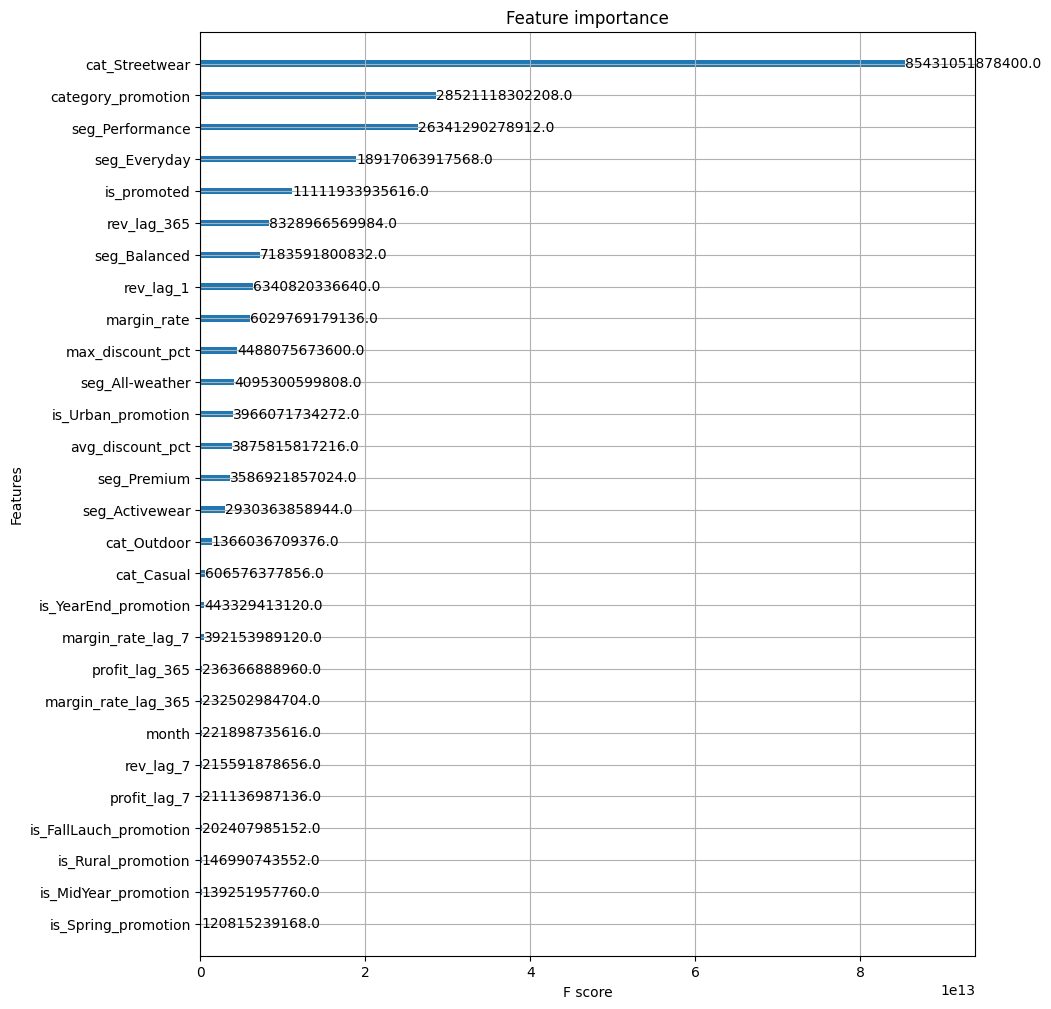

In [542]:
# from xgboost import plot_importance

# # 1. Train lại một model với bộ tham số xịn nhất Optuna vừa tìm được
# best_model = XGBRegressor(**study.best_params)
# best_model.fit(X_train, y_train)

# # 2. Vẽ biểu đồ quan trọng theo GÁNH (Gain) - Cái này chuẩn hơn Weight
# fig, ax = plt.subplots(figsize=(10, 12))
# plot_importance(best_model, importance_type='gain', ax=ax)
# plt.show()

from xgboost import plot_importance
import matplotlib.pyplot as plt # Đảm bảo bạn đã import thư viện này để vẽ hình

# 1. Train lại một model với bộ tham số xịn nhất Optuna vừa tìm được
best_model = XGBRegressor(**study.best_params)

# --- DỌN DẸP LẠI DỮ LIỆU (Giống hệt bước trước) ---
X_train_clean = X_train.loc[:, ~X_train.columns.duplicated()].copy()
y_train_1d = y_train.squeeze()
# ---------------------------------------------------

# Fit model bằng dữ liệu ĐÃ CLEAN
best_model.fit(X_train_clean, y_train_1d)

# 2. Vẽ biểu đồ quan trọng theo GÁNH (Gain) - Cái này chuẩn hơn Weight
fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(best_model, importance_type='gain', ax=ax)
plt.show()

In [543]:
import xgboost as xgb

best_param={
    'n_estimators': 1381,
    'max_depth': 3, 
    'learning_rate': 0.015490364108594305, 
    'subsample': 0.6349397154351263, 
    'colsample_bytree': 0.6857173094570057, 
    'reg_alpha': 1.1585930474696895, 
    'reg_lambda': 0.03433161121687512
}
model_rev = XGBRegressor(**best_param)
model_rev.fit(df_daily[features], df_daily['Revenue'])

model_cogs= XGBRegressor(**best_param)
model_cogs.fit(df_daily[features], df_daily['COGS'])

print("✅ Đã huấn luyện xong bộ đôi 'não bộ' cho Model!")

from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import r2_score
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'mse': 'neg_mean_squared_error', 'r2': 'r2'}

# Chấm điểm thử cho Model Revenue
cv_results = cross_validate(model_rev, df_daily[features], df_daily['Revenue'], 
                            cv=kf, scoring=scoring)

# Tính toán các chỉ số trung bình từ kết quả CV
avg_mse = -cv_results['test_mse'].mean()
avg_rmse = np.sqrt(avg_mse)
avg_r2 = cv_results['test_r2'].mean()

print(f"📊 Kết quả Đánh giá 5-Fold:")
print(f"   - MSE:  {avg_mse:,.2f}")
print(f"   - RMSE: {avg_rmse:,.2f}")
print(f"   - R²:   {avg_r2:.4f}")

train_pred = model_rev.predict(df_daily[features])
train_r2 = r2_score(df_daily['Revenue'], train_pred)
print(f"Điểm trên tập Train: {train_r2:.4f}")

AttributeError: 'DataFrame' object has no attribute 'dtype'

In [ ]:
# ĐÁNH GIÁ MÔ HÌNH REVENUE
cv_rev = cross_validate(model_rev, df_daily[features], df_daily['Revenue'], 
                         cv=kf, scoring=scoring)

# ĐÁNH GIÁ MÔ HÌNH COGS
cv_cogs = cross_validate(model_cogs, df_daily[features], df_daily['COGS'], 
                          cv=kf, scoring=scoring)

# TỔNG KẾT KẾT QUẢ
print(f"[REVENUE] Local RMSE: {np.sqrt(-cv_rev['test_mse'].mean()):,.2f} | R²: {cv_rev['test_r2'].mean():.4f}")
print(f"[COGS]    Local RMSE: {np.sqrt(-cv_cogs['test_mse'].mean()):,.2f} | R²: {cv_cogs['test_r2'].mean():.4f}")

[REVENUE] Local RMSE: 307,191.12 | R²: 0.9857
[COGS]    Local RMSE: 264,055.95 | R²: 0.9858


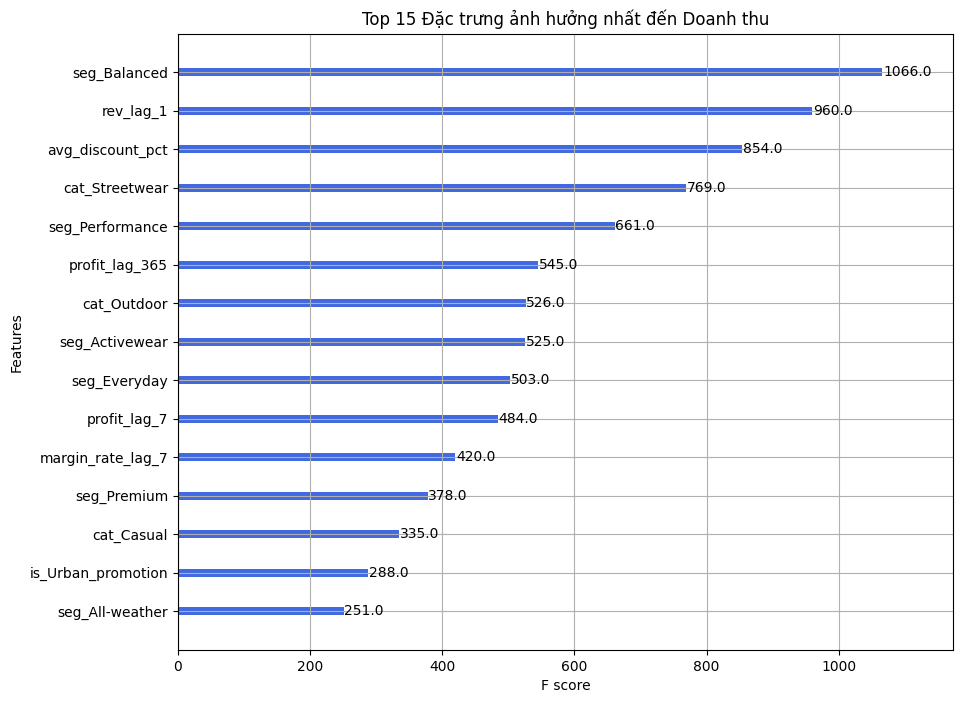

In [ ]:
from xgboost import plot_importance

# 1. Thiết lập kích thước biểu đồ
fig, ax = plt.subplots(figsize=(10, 8))

# 2. Vẽ biểu đồ quan trọng (Dùng 'weight' để xem tần suất biến đó được dùng để phân loại)
plot_importance(model_rev, ax=ax, max_num_features=15, importance_type='weight', color='royalblue')

plt.title("Top 15 Đặc trưng ảnh hưởng nhất đến Doanh thu")
plt.show()

In [ ]:
ALL_DATES = sorted(df_daily['Date'].unique())

def get_lag_safe(date_obj, lag_days, key, hist_dict):
    target_date = date_obj - pd.Timedelta(days=lag_days)
    
    if target_date in hist_dict:
        return hist_dict[target_date].get(key, 0)
    
    valid_dates = [d for d in ALL_DATES if d <= target_date]
    if valid_dates:
        closest_date = valid_dates[-1]
        if abs((closest_date - target_date).days) <= 3:
            return hist_dict.get(closest_date, {}).get(key, 0)
    return 0

In [ ]:
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

# Hàm helper lấy giá trị từ dictionary lịch sử
def get_lag_val(date_obj, lag_days, key, hist_dict):
    target_ds = date_obj - pd.Timedelta(days=lag_days)
    if target_ds in hist_dict:
        return hist_dict[target_ds].get(key, 0)
    return 0

# 1. Tạo tập validation (2 tháng cuối 2022)
val_start = '2022-11-01'
val_end = '2022-12-31'

# Lấy 400 ngày cuối cùng của tập train để làm lịch sử cho validation
historical_val = df_daily[['Date', 'Revenue', 'Profit']].iloc[-400:-30].copy()
historical_val = historical_val.rename(columns={'Date': 'ds', 'Revenue': 'y', 'Profit': 'profit'})
historical_val_dict = historical_val.set_index('ds').to_dict('index')

# 2. Tạo đặc trưng tĩnh theo tháng
train_monthly_avg = df_daily.groupby('month')[
    ['seg_Balanced', 'seg_Activewear', 'seg_Premium', 'seg_All-weather', 'seg_Everyday', 'seg_Performance', 
    'cat_Casual', 'cat_Outdoor', 'cat_Streetwear', 
    'rev_lag_1', 'rev_lag_7', 'rev_lag_365', 
    'profit_lag_7', 'profit_lag_365', 
    'margin_rate', 'margin_rate_lag_7', 'margin_rate_lag_365', 
    'profit_lag_7', 'profit_lag_365', 
    'month', 'is_promoted', 
    'avg_discount_pct', 'max_discount_pct',
    'is_Spring_promotion', 'is_MidYear_promotion', 'is_FallLauch_promotion',
    'is_YearEnd_promotion', 'is_Rural_promotion', 'is_Urban_promotion',
    'category_promotion']
].mean().to_dict('index')

# 3. Tìm tỷ lệ blending tối ưu
best_score = float('inf')
best_ratio = 0.8
best_growth = 1.03

print("Đang tìm tỷ lệ blending tối ưu...")
for growth in [0.99, 1.0, 1.01]:
    for ratio in [0.45, 0.5, 0.55, 0.60]:
        val_results = []
        temp_dict = historical_val_dict.copy()
        
        for current_date in pd.date_range(start=val_start, end=val_end):
            month = current_date.month
            current_features = {
                'month': month,
                'day_of_week': current_date.dayofweek,
                'is_weekend': 1 if current_date.dayofweek >= 5 else 0,
                'is_special': 1 if current_date.strftime('%m-%d') in ['01-01', '02-14', '04-30', '05-01', '12-31', '12-24', '12-25'] else 0,
                'is_payday': 1 if (current_date.day == 15 or current_date.is_month_end) else 0,
                'rev_lag_1': get_lag_safe(current_date, 1, 'y', temp_dict),
                'profit_lag_7': get_lag_safe(current_date, 7, 'profit', temp_dict),
                'profit_lag_365': get_lag_safe(current_date, 365, 'profit', temp_dict),
            }
            
            # Tính margin_rate_lag_7
            rev_lag_7 = get_lag_safe(current_date, 7, 'y', temp_dict)
            profit_lag_7_val = current_features['profit_lag_7']
            current_features['margin_rate_lag_7'] = profit_lag_7_val / (rev_lag_7 + 1)
            
            # Thêm đặc trưng tĩnh
            for k, v in train_monthly_avg.get(month, {}).items():
                current_features[k] = v
            
            X_pred = pd.DataFrame([current_features])[features]
            revenue_pred = model_rev.predict(X_pred)[0]
            _cogspred = model_cogs.predict(X_pred)[0]
            
            hist_rev = get_lag_safe(current_date, 365, 'y', temp_dict)
            hist_cogs = hist_rev - get_lag_safe(current_date, 365, 'profit', temp_dict) if hist_rev > 0 else 0
            
            final_rev = (hist_rev * growth * ratio) + (revenue_pred * (1 - ratio))
            final_cogs = (hist_cogs * growth * ratio) + (cogs_pred * (1 - ratio))
            
            temp_dict[current_date] = {'y': final_rev, 'profit': final_rev - final_cogs}
            val_results.append({'Date': current_date, 'Revenue': final_rev, 'COGS': final_cogs})
        
        # Đánh giá
        val_df = pd.DataFrame(val_results)
        actual_train = df_daily[df_daily['Date'].between(val_start, val_end)]
        val_merged = val_df.merge(actual_train[['Date', 'Revenue', 'COGS']], on='Date', suffixes=('_pred', '_actual'))
        
        mse_rev = mean_squared_error(val_merged['Revenue_actual'], val_merged['Revenue_pred'])
        mse_cogs = mean_squared_error(val_merged['COGS_actual'], val_merged['COGS_pred'])
        total_mse = mse_rev + mse_cogs
        
        if total_mse < best_score:
            best_score = total_mse
            best_ratio = ratio
            best_growth = growth

print(f"\nTỶ LỆ BLENDING TỐI ƯU:")
print(f"   - History weight: {best_ratio:.0%}")
print(f"   - AI weight:      {1-best_ratio:.0%}")
print(f"   - Growth factor:  {best_growth}")
print(f"   - Best MSE:       {best_score:,.2f}")

Đang tìm tỷ lệ blending tối ưu...

TỶ LỆ BLENDING TỐI ƯU:
   - History weight: 45%
   - AI weight:      55%
   - Growth factor:  0.99
   - Best MSE:       694,920,594,628.14


In [ ]:
from tqdm import tqdm

print("Bắt đầu quá trình dự đoán tuần tự...")

historical_df = df_daily[['Date', 'Revenue', 'Profit']].iloc[-370:].copy()
historical_df = historical_df.rename(columns={'Date': 'ds', 'Revenue': 'y', 'Profit': 'profit'})
historical_dict = historical_df.set_index('ds').to_dict('index')

future_dates = pd.date_range(start='2023-01-01', end='2024-07-01')
results = []

# Các đặc trưng tĩnh (không thay đổi theo thời gian hoặc lấy trung bình tháng)
train_monthly_avg = df_daily.groupby('month')[
    ['seg_Balanced', 'seg_Activewear', 'seg_Premium', 'seg_All-weather', 'seg_Everyday', 'seg_Performance', 
    'cat_Casual', 'cat_Outdoor', 'cat_Streetwear', 
    'rev_lag_1', 'rev_lag_7', 'rev_lag_365', 
    'profit_lag_7', 'profit_lag_365', 
    'margin_rate', 'margin_rate_lag_7', 'margin_rate_lag_365', 
    'profit_lag_7', 'profit_lag_365', 
    'month', 'is_promoted', 
    'avg_discount_pct', 'max_discount_pct',
    'is_Spring_promotion', 'is_MidYear_promotion', 'is_FallLauch_promotion',
    'is_YearEnd_promotion', 'is_Rural_promotion', 'is_Urban_promotion',
    'category_promotion']
].mean().to_dict('index')
# Dự đoán tuần tự
for current_date in tqdm(future_dates, desc="Đang dự đoán"):
    month = current_date.month
    
    # Tạo feature cho ngày hiện tại
    current_features = {
        'month': month,
        'day_of_week': current_date.dayofweek,
        'is_weekend': 1 if current_date.dayofweek >= 5 else 0,
        'is_special': 1 if current_date.strftime('%m-%d') in ['01-01', '02-14', '04-30', '05-01', '12-31', '12-24', '12-25'] else 0,
        'is_payday': 1 if (current_date.day == 15 or current_date.is_month_end) else 0,
        'rev_lag_1': get_lag_safe(current_date, 1, 'y', historical_dict),
        'profit_lag_7': get_lag_safe(current_date, 7, 'profit', historical_dict),
        'profit_lag_365': get_lag_safe(current_date, 365, 'profit', historical_dict),
        'margin_rate_lag_7': get_lag_safe(current_date, 7, 'profit', historical_dict) / (get_lag_safe(current_date, 7, 'y', historical_dict) + 1),
    }
    
    # Thêm các đặc trưng tĩnh từ dữ liệu trung bình tháng
    for k, v in train_monthly_avg.get(month, {}).items():
        current_features[k] = v

    # Dự đoán Doanh thu và Giá vốn
    X_pred = pd.DataFrame([current_features])[features]
    revenue_pred = model_rev.predict(X_pred)[0]
    cogs_pred = model_cogs.predict(X_pred)[0]

    # Blending
    hist_rev = get_lag_safe(current_date, 365, 'y', historical_dict)
    hist_cogs = hist_rev - get_lag_safe(current_date, 365, 'profit', historical_dict) if hist_rev > 0 else 0

    growth_factor = 1.00
    final_rev = (hist_rev * growth_factor * 0.5) + (revenue_pred * 0.5)
    final_cogs = (hist_cogs * growth_factor * 0.5) + (cogs_pred * 0.5)

    # Cập nhật kết quả vào historical_dict cho các lần dự đoán tiếp theo
    historical_dict[current_date] = {'y': final_rev, 'profit': final_rev - final_cogs}
    
    # Lưu kết quả
    results.append({
        'Date': current_date.strftime('%Y-%m-%d'),
        'Revenue': final_rev,
        'COGS': final_cogs
    })

# Tạo và lưu file submission
submission_final = pd.DataFrame(results)
submission_final.to_csv('submission_vi_v2.csv', index=False)
print(f"✅ File 'submission_vi_v2.csv' đã sẵn sàng nộp.")

Bắt đầu quá trình dự đoán tuần tự...


Đang dự đoán: 100%|██████████| 548/548 [00:22<00:00, 24.31it/s]

✅ File 'submission_vi.csv' đã sẵn sàng nộp.
